# Validation Analysis
This notebook is for analysing the validation data.

Rafa, vc adicionar aqui, eu sou mt ruim de fazer descrição de notebook


In [1]:
#Includes:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mlp
import seaborn as sns

In [2]:
#cuda 
torch.set_default_device('cuda')

In [ ]:
#Setting the imports
import sys
import os

current_dir = os.getcwd() 
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))
sys.path.append(utils_path)
sys.path.append(models_path)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from StaticMaskTraining import StaticMaskTraining
from NotebookUtils import animate_notebook
from NotebookUtils import load_checkpoints

Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models


## Analise de treinamento:
- Grafico de todos as metricas em proporção aos loss e ao parâmetro de validação

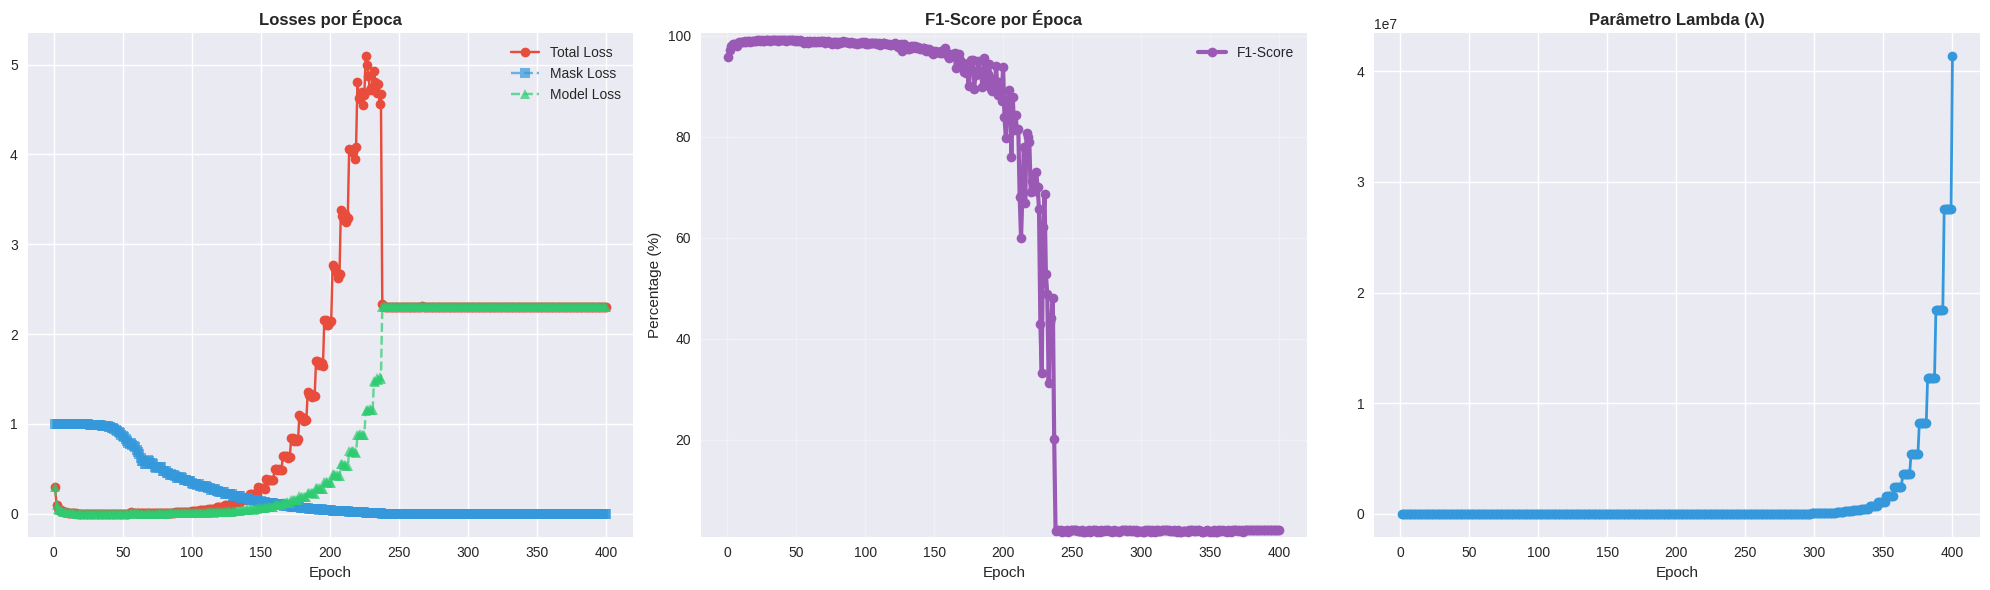

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# CONFIGURAÇÃO DE EXIBIÇÃO
# Opções: "Accuracy", "Precision", "Recall", "F1-Score"
# =========================================================================
METRICA_PARA_PLOTAR = "F1-Score" 

# --- 1. COLETA DE DADOS ---
epochs = []
total_losses = []
lambdas = []
mask_loss = []
model_loss = []

# Dicionário para armazenar as listas das métricas
metrics_data = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for check in load_checkpoints("lenet_mnist_01"):
    epochs.append(check['epoch'])
    total_losses.append(check['total_loss'])
    lambdas.append(check['lambda'])
    mask_loss.append(check['mask_loss'])
    model_loss.append(check['model_loss'])
    
    # --- CÁLCULO DE MÉTRICAS A PARTIR DA CM ---
    cm = np.array(check['cm'])
    
    # Acurácia Global
    acc = np.sum(np.diag(cm)) / np.sum(cm)
    
    # Macro Average (TP, FP, FN)
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    
    eps = 1e-9
    precision = np.mean(tp / (tp + fp + eps))
    recall = np.mean(tp / (tp + fn + eps))
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    # Salva no dicionário (escala 0-100)
    metrics_data["Accuracy"].append(acc * 100)
    metrics_data["Precision"].append(precision * 100)
    metrics_data["Recall"].append(recall * 100)
    metrics_data["F1-Score"].append(f1 * 100)

# --- 2. CONFIGURAÇÃO DA PLOTAGEM ---
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# Cores para cada métrica caso queira variar
colors = {"Accuracy": "#2ecc71", "Precision": "#f1c40f", "Recall": "#e67e22", "F1-Score": "#9b59b6"}

# GRÁFICO 1: Losses
axes[0].plot(epochs, total_losses, 'o-', color='#e74c3c', label='Total Loss')
axes[0].plot(epochs, mask_loss,   's--', color='#3498db', label='Mask Loss', alpha=0.7)
axes[0].plot(epochs, model_loss,  '^--', color='#2ecc71', label='Model Loss', alpha=0.7)
axes[0].set_title('Losses por Época', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# =========================================================================
# GRÁFICO 2: Métrica Selecionada
# =========================================================================
selected_data = metrics_data[METRICA_PARA_PLOTAR]
axes[1].plot(epochs, selected_data, 'o-', linewidth=3, color=colors[METRICA_PARA_PLOTAR], label=METRICA_PARA_PLOTAR)

axes[1].set_title(f'{METRICA_PARA_PLOTAR} por Época', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(min(selected_data)-1, 100.5) # Zoom dinâmico no topo
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# GRÁFICO 3: Lambda
axes[2].plot(epochs, lambdas, 'o-', color='#3498db', linewidth=2)
axes[2].set_title('Parâmetro Lambda (λ)', fontweight='bold')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

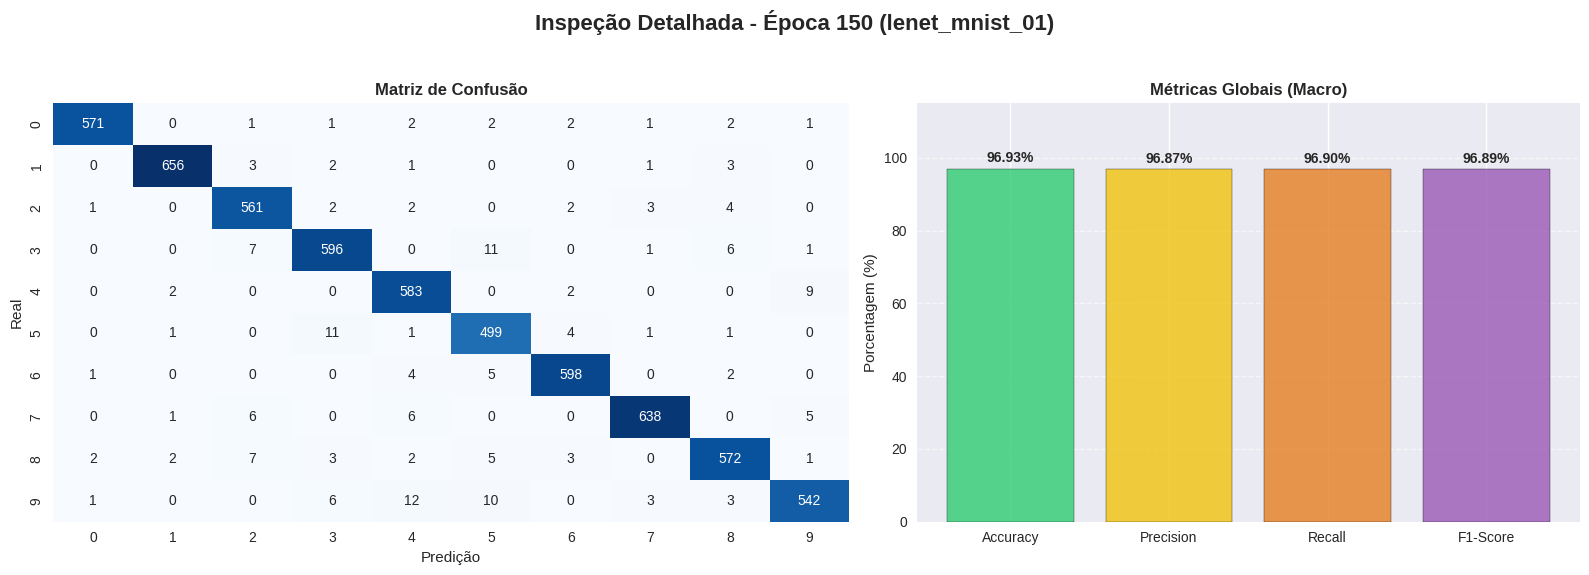

In [6]:

# =========================================================================
# CONFIGURAÇÃO DE INSPEÇÃO
# =========================================================================
INDICE_EPOCA = 150  # Escolha o número da época que deseja inspecionar
TRAINING_ID  = "lenet_mnist_01"

def plot_checkpoint_stats(training_id, epoch_idx):
    # 1. Tentar carregar o checkpoint específico
    # (Ajuste o caminho conforme sua estrutura: ../../checkpoints/ID/...)
    path = f"../../checkpoints/{training_id}/checkpoint_epoch_{epoch_idx}.pt"
    
    try:
        check = torch.load(path, map_location='cpu', weights_only=False)
    except FileNotFoundError:
        print(f"❌ Erro: Checkpoint da época {epoch_idx} não encontrado em: {path}")
        return

    cm = np.array(check['cm'])
    
    # --- CÁLCULO DAS MÉTRICAS ---
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    eps = 1e-9
    
    acc = np.sum(tp) / np.sum(cm)
    prec = np.mean(tp / (tp + fp + eps))
    rec = np.mean(tp / (tp + fn + eps))
    f1 = 2 * (prec * rec) / (prec + rec + eps)
    
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [acc * 100, prec * 100, rec * 100, f1 * 100]

    # --- PLOTAGEM ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.2, 1]})
    fig.suptitle(f"Inspeção Detalhada - Época {epoch_idx} ({training_id})", fontsize=16, fontweight='bold')

    # Painel 1: Heatmap da Matriz de Confusão
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
    axes[0].set_title("Matriz de Confusão", fontweight='bold')
    axes[0].set_xlabel("Predição")
    axes[0].set_ylabel("Real")

    # Painel 2: Histograma (Barra) de Métricas
    colors = ['#2ecc71', '#f1c40f', '#e67e22', '#9b59b6']
    bars = axes[1].bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
    
    # Adiciona os valores no topo das barras
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

    axes[1].set_title("Métricas Globais (Macro)", fontweight='bold')
    axes[1].set_ylim(0, 115) # Espaço extra para o texto acima da barra
    axes[1].set_ylabel("Porcentagem (%)")
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Executa a inspeção
plot_checkpoint_stats(TRAINING_ID, INDICE_EPOCA)

In [8]:
masks = []

for i, checkpoint in enumerate(load_checkpoints("lenet_mnist_01")):
    loss = checkpoint['mask_loss']
    s = checkpoint['lambda']
    accuracy = checkpoint['accuracy']
    model = checkpoint['model_state_dict']
    mask = checkpoint['mask_state_dict']
    mask = mask['mask'].squeeze().cpu().detach().numpy()
    rounded = torch.round(torch.sigmoid(torch.tensor(mask, device='cpu')))
    masks.append(rounded)
    
animate_notebook(masks, cmap="gray", vmin=0, vmax=1)